# 08 — Prédiction sur Hanoï

Objectif :
1. Télécharger carte + bâtiments OSMnx des zones d'étude
2. Extraire les **mêmes features de morphologie que le notebook 04** (méthodo du papier)
3. Charger le modèle pré-entraîné (notebook 06), le calibrer avec nos mesures terrain
4. Prédire le niveau de bruit sur toute la zone
5. Exporter la carte de bruit (CSV + GeoJSON)

In [1]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import numpy as np
import joblib
import folium
from shapely.geometry import Point
import warnings
warnings.filterwarnings('ignore')

# Zone d'étude Hanoï — "Bach Khoa" est géocodé comme un POINT dans OSM
# (pas un polygone de quartier), donc on prend un rayon autour du centre
STUDY_AREA = 'Bach Khoa, Hanoi, Vietnam'  # ajuste selon besoin
RADIUS_M = 1500                            # rayon de la zone d'étude
GRAPH_PATH = '../data/processed/hanoi_roads.graphml'

/Users/phocidae/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


1542 segments routiers


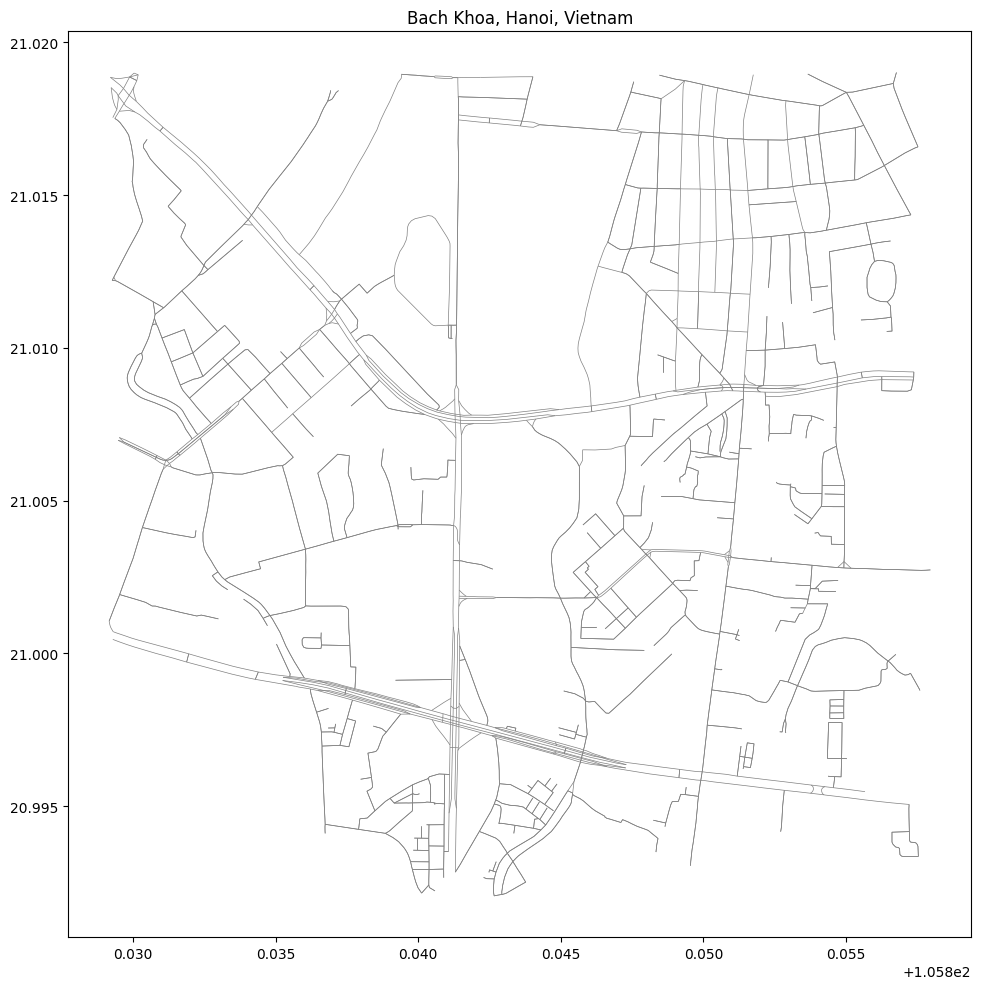

In [2]:
import os

CENTER = ox.geocode(STUDY_AREA)  # (lat, lon)

if not os.path.exists(GRAPH_PATH):
    print(f'Téléchargement carte : {STUDY_AREA} (rayon {RADIUS_M} m)...')
    G = ox.graph_from_point(CENTER, dist=RADIUS_M, network_type='drive')
    ox.save_graphml(G, GRAPH_PATH)
    print('Sauvegardé.')
else:
    G = ox.load_graphml(GRAPH_PATH)

nodes, edges = ox.graph_to_gdfs(G)
print(f'{len(edges)} segments routiers')

# Affiche la zone
ax = edges.plot(figsize=(10, 10), linewidth=0.5, color='gray')
ax.set_title(STUDY_AREA)
import matplotlib.pyplot as plt
plt.tight_layout()
plt.savefig('../outputs/maps/hanoi_osm.png', dpi=150)
plt.show()

In [3]:
# Génère une grille de points sur la zone d'étude
bounds = edges.total_bounds  # [minx, miny, maxx, maxy]
GRID_STEP = 0.0003  # ~30 mètres

lons = np.arange(bounds[0], bounds[2], GRID_STEP)
lats = np.arange(bounds[1], bounds[3], GRID_STEP)
grid_points = [(lat, lon) for lat in lats for lon in lons]
print(f'Grille : {len(grid_points)} points')

grid_df = pd.DataFrame(grid_points, columns=['latitude', 'longitude'])

Grille : 8640 points


In [4]:
# Features de morphologie v2 pour chaque point de la grille
# v2 = built_area_ratio (surface bâtie / surface du disque) au lieu du comptage —
# invariant aux conventions de cartographie OSM (voir scripts/train_v2_invariant.py)
R = 300
AREA_M2 = np.pi * R ** 2
CRS_HANOI = 'EPSG:32648'  # UTM 48N

# Bâtiments de la zone (même rayon que le graphe, + R pour couvrir les buffers)
buildings = ox.features_from_point(CENTER, tags={'building': True}, dist=RADIUS_M + R)
buildings = buildings[buildings.geometry.geom_type.isin(['Polygon', 'MultiPolygon'])]
print(f'{len(buildings)} bâtiments')

pts = gpd.GeoDataFrame(
    grid_df.copy(),
    geometry=gpd.points_from_xy(grid_df.longitude, grid_df.latitude),
    crs='EPSG:4326'
).to_crs(CRS_HANOI)

bld = buildings.to_crs(CRS_HANOI)
bld['area_m2'] = bld.geometry.area
bld = bld.set_geometry(bld.geometry.centroid)
edg = edges.to_crs(CRS_HANOI).reset_index(drop=True)
nod = nodes.to_crs(CRS_HANOI).reset_index(drop=True)

buf = gpd.GeoDataFrame({'pt_id': range(len(pts))},
                       geometry=pts.geometry.buffer(R), crs=CRS_HANOI)

# Ratio de surface bâtie
jb = gpd.sjoin(bld[['geometry', 'area_m2']], buf, predicate='within')
area_sum = jb.groupby('pt_id')['area_m2'].sum()
pts['built_area_ratio'] = [min(area_sum.get(i, 0) / AREA_M2, 1.0) for i in range(len(pts))]

# Road density (km/km²)
jr = gpd.sjoin(edg[['geometry']], buf, predicate='intersects')
rl = jr.groupby('pt_id').apply(lambda g: g.geometry.length.sum())
pts['road_density_km_km2'] = [(rl.get(i, 0) / 1000) / (AREA_M2 / 1e6) for i in range(len(pts))]

# Intersection count
jn = gpd.sjoin(nod[['geometry']], buf, predicate='within').groupby('pt_id').size()
pts['intersection_count'] = [jn.get(i, 0) for i in range(len(pts))]

# Distance à la route (vectorisé — bien plus rapide que la boucle)
near = gpd.sjoin_nearest(pts[['geometry']], edg[['geometry']], distance_col='dist_road_m')
pts['dist_road_m'] = near.groupby(near.index)['dist_road_m'].min()

grid_df = pd.DataFrame(pts.drop(columns='geometry'))
grid_df['hour'] = 8       # heure cible de la prédiction
grid_df['is_weekend'] = 0
grid_df.to_parquet('../data/processed/hanoi_grid_features.parquet', index=False)
print('Features grille sauvegardées.')

9771 bâtiments


Features grille sauvegardées.


In [5]:
# Charge le modèle v2 pré-entraîné sur Sunbird (features invariantes)
model = joblib.load('../outputs/models/surrogate_lgbm_v2_uganda.pkl')

FEATURES = ['built_area_ratio', 'road_density_km_km2', 'intersection_count',
            'dist_road_m', 'hour', 'is_weekend']
grid_df['noise_pred_dB'] = model.predict(grid_df[FEATURES])

print(grid_df['noise_pred_dB'].describe())

count    8640.000000
mean       42.722393
std         7.187162
min        24.085172
25%        37.074249
50%        42.150658
75%        48.005025
max        71.395756
Name: noise_pred_dB, dtype: float64


In [6]:
# ============================================================
#  TRANSFER LEARNING : modèle Uganda v2 → données Hanoï
#  Tourne dès que data/raw/hanoi/measurements.csv existe (notebook 07)
# ============================================================
import os
import lightgbm as lgb

MEASURES = '../data/raw/hanoi/measurements.csv'

if os.path.exists(MEASURES):
    hanoi = pd.read_csv(MEASURES, parse_dates=['timestamp'])
    hanoi['hour'] = hanoi['timestamp'].dt.hour
    hanoi['is_weekend'] = hanoi['timestamp'].dt.dayofweek.isin([5, 6]).astype(int)

    # --- 0. OSM AUTOUR DE NOS POINTS (les sites de mesure peuvent être
    #        ailleurs que la zone d'étude de la carte, ex. Ocean Park) ---
    MARGIN = 0.006  # ~600 m, pour couvrir les buffers R=300m
    hbbox = (hanoi.longitude.min() - MARGIN, hanoi.latitude.min() - MARGIN,
             hanoi.longitude.max() + MARGIN, hanoi.latitude.max() + MARGIN)
    HB_PATH = '../data/processed/hanoi_sites_buildings.gpkg'
    HG_PATH = '../data/processed/hanoi_sites_roads.graphml'
    if not os.path.exists(HG_PATH):
        print('Téléchargement OSM autour des points de mesure...')
        ox.settings.timeout = 600
        hb = ox.features_from_bbox(hbbox, tags={'building': True})
        hb = hb[hb.geometry.geom_type.isin(['Polygon', 'MultiPolygon'])]
        hb[['geometry']].to_file(HB_PATH, driver='GPKG')
        Gh = ox.graph_from_bbox(hbbox, network_type='drive')
        ox.save_graphml(Gh, HG_PATH)
    hbld = gpd.read_file(HB_PATH).to_crs(CRS_HANOI)
    hbld['area_m2'] = hbld.geometry.area
    hbld = hbld.set_geometry(hbld.geometry.centroid)
    Gh = ox.load_graphml(HG_PATH)
    hnod, hedg = ox.graph_to_gdfs(Gh)
    hedg = hedg.to_crs(CRS_HANOI).reset_index(drop=True)
    hnod = hnod.to_crs(CRS_HANOI).reset_index(drop=True)
    print(f'{len(hbld)} bâtiments, {len(hedg)} segments autour des sites')

    # --- 1. Mêmes features v2 pour NOS points mesurés ---
    hpts = gpd.GeoDataFrame(
        hanoi, geometry=gpd.points_from_xy(hanoi.longitude, hanoi.latitude),
        crs='EPSG:4326').to_crs(CRS_HANOI)
    hbuf = gpd.GeoDataFrame({'pt_id': range(len(hpts))},
                            geometry=hpts.geometry.buffer(R), crs=CRS_HANOI)

    jb = gpd.sjoin(hbld[['geometry', 'area_m2']], hbuf, predicate='within')
    area_sum = jb.groupby('pt_id')['area_m2'].sum()
    hpts['built_area_ratio'] = [min(area_sum.get(i, 0) / AREA_M2, 1.0) for i in range(len(hpts))]
    jr = gpd.sjoin(hedg[['geometry']], hbuf, predicate='intersects')
    rl = jr.groupby('pt_id').apply(lambda g: g.geometry.length.sum())
    hpts['road_density_km_km2'] = [(rl.get(i, 0) / 1000) / (AREA_M2 / 1e6) for i in range(len(hpts))]
    jn = gpd.sjoin(hnod[['geometry']], hbuf, predicate='within').groupby('pt_id').size()
    hpts['intersection_count'] = [jn.get(i, 0) for i in range(len(hpts))]
    near = gpd.sjoin_nearest(hpts[['geometry']], hedg[['geometry']], distance_col='dist_road_m')
    hpts['dist_road_m'] = near.groupby(near.index)['dist_road_m'].min()

    X_hanoi = pd.DataFrame(hpts.drop(columns='geometry'))[FEATURES]
    y_hanoi = hanoi['noise_dB']

    # --- 2. Split train/test sur NOS points pour mesurer honnêtement ---
    from sklearn.model_selection import train_test_split
    Xh_tr, Xh_te, yh_tr, yh_te = train_test_split(
        X_hanoi, y_hanoi, test_size=0.3, random_state=42)

    # --- 3-4. Trois méthodes : brut / offset / fine-tuning ---
    from sklearn.metrics import mean_absolute_error, r2_score
    from scipy.stats import pearsonr

    def report(name, pred):
        """MAE toujours ; R² et r seulement si le test a de la dynamique.
        Sur des points tous aussi bruyants (std faible), R²/r ne veulent rien dire :
        un MAE flatteur peut cacher un modèle qui ne classe rien (cf. ROADMAP)."""
        mae = mean_absolute_error(yh_te, pred)
        if yh_te.std() >= 4 and len(yh_te) >= 8:
            print(f'  {name:24} MAE {mae:5.1f} dB | R² {r2_score(yh_te, pred):6.2f} | r {pearsonr(yh_te, pred)[0]:5.2f}')
        else:
            print(f'  {name:24} MAE {mae:5.1f} dB | R²/r N/A (test trop homogène)')
        return mae

    pred_raw = model.predict(Xh_te)
    offset = (yh_tr - model.predict(Xh_tr)).mean()
    pred_off = model.predict(Xh_te) + offset
    finetuned = lgb.train(
        {'objective': 'regression', 'learning_rate': 0.01,
         'num_leaves': 15, 'verbose': -1},
        lgb.Dataset(Xh_tr, yh_tr),
        num_boost_round=100,
        init_model=model.booster_,          # <-- on part du modèle pré-entraîné
    )
    pred_ft = finetuned.predict(Xh_te)

    print(f'n = {len(hanoi)} mesures ({len(Xh_tr)} calib / {len(Xh_te)} test, '
          f'plage dB {yh_te.min():.0f}-{yh_te.max():.0f}, std {yh_te.std():.1f})')
    base_mae = (yh_te - yh_tr.mean()).abs().mean()
    print(f'  {"baseline (= moyenne)":24} MAE {base_mae:5.1f} dB  <- à battre')
    mae_raw = report('Uganda brut', pred_raw)
    mae_offset = report(f'+ offset ({offset:+.0f} dB)', pred_off)
    mae_ft = report('fine-tuné', pred_ft)
    if mae_offset >= base_mae:
        print('  /!\\ aucune méthode ne bat la moyenne : test set sans dynamique '
              '(donnees trop homogenes). Collecter des points calmes.')

    # --- 5. On garde la meilleure méthode et on applique à la grille ---
    if mae_ft <= mae_offset:
        print('>> Fine-tuning retenu')
        grid_df['noise_pred_dB'] = finetuned.predict(grid_df[FEATURES])
        finetuned.save_model('../outputs/models/surrogate_lgbm_hanoi.txt')
    else:
        print('>> Calibration par offset retenue (plus robuste avec peu de points)')
        grid_df['noise_pred_dB'] = model.predict(grid_df[FEATURES]) + offset
else:
    print('Pas encore de mesures Hanoï — la carte reste sur le modèle Uganda brut.')
    print('Lance le notebook 07 après ta première session terrain.')

Téléchargement OSM autour des points de mesure...


49149 bâtiments, 12887 segments autour des sites


n = 215 mesures (150 calib / 65 test, plage dB 50-82, std 8.3)
  baseline (= moyenne)     MAE   7.4 dB  <- à battre
  Uganda brut              MAE  17.4 dB | R²  -5.05 | r  0.20
  + offset (+19 dB)        MAE   8.8 dB | R²  -0.85 | r  0.20
  fine-tuné                MAE   8.6 dB | R²  -0.75 | r  0.43
  /!\ aucune méthode ne bat la moyenne : test set sans dynamique (donnees trop homogenes). Collecter des points calmes.
>> Fine-tuning retenu


In [7]:
# Export pour GAMA et visualisation
output = grid_df[['latitude', 'longitude', 'noise_pred_dB']]
output.to_csv('../outputs/maps/hanoi_noise_map.csv', index=False)

gdf = gpd.GeoDataFrame(
    output,
    geometry=gpd.points_from_xy(output.longitude, output.latitude),
    crs='EPSG:4326'
)
gdf.to_file('../outputs/maps/hanoi_noise_map.geojson', driver='GeoJSON')
print('Exports sauvegardés.')

# Carte interactive — cellules colorées par dB prédit.
# (PAS une HeatMap folium : elle visualise la DENSITÉ de points, et notre
#  grille régulière sature donc en rouge uniforme partout.)
import branca.colormap as cm
vmin, vmax = grid_df.noise_pred_dB.quantile([0.02, 0.98])
cmap = cm.LinearColormap(['green', 'yellow', 'orange', 'red', 'darkred'],
                         vmin=vmin, vmax=vmax, caption='Bruit prédit (dB)')

m = folium.Map(location=[grid_df.latitude.mean(), grid_df.longitude.mean()],
               zoom_start=15, tiles='OpenStreetMap')
half = GRID_STEP / 2
for _, r in grid_df.iterrows():
    folium.Rectangle(
        [(r.latitude - half, r.longitude - half),
         (r.latitude + half, r.longitude + half)],
        color=None, fill=True, fill_opacity=0.45,
        fill_color=cmap(min(max(r.noise_pred_dB, vmin), vmax)),
    ).add_to(m)
cmap.add_to(m)
m.save('../outputs/maps/hanoi_heatmap.html')
m

Exports sauvegardés.
